In [1]:
from time import time
import copy
import math

import torch
import torch_geometric
import GNNTrackingTools as GTT
import models

from torch import optim
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, DataLoader, InMemoryDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

import sklearn
import inspect



/opt/anaconda3/envs/PyG_sklearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data and setup Graph dataset

In [12]:
tracker_name = 'Recoil'  # Either 'Tagger' or 'Recoil'
n_primaries = 4      # Number of primaries simulated per event
use_Edep = False       # Whether to use energy deposition as a external effect in the Interaction Network

# Read data file
df = pd.read_pickle("/Users/mghrear/data/LDMX_GNN/4e_run1.pkl")

# Compute Info needed to build graphs
# GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
df_graph = pd.DataFrame()
df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo, axis=1, args=(n_primaries, tracker_name,), result_type='expand')
df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']
df_graph['Digi_Edep'] = df[f'{tracker_name}_Digi_Edep']
df_graph['TruthTrack_ID'] = df[f'{tracker_name}_TruthID']
df_graph['TruthTrack_P'] = df[f'{tracker_name}_TruthP']
# Get the truth momentum for every spacepoint (defined by [Digi_x,Digi_y,Digi_z])
# This is done by matching the trackID to the TruthTrack_ID
# If there is no match (tracks with fewer than min_hits, or secondaries), a truth P of 0 is assigned
# This should only by used for Recoil, for Tagger we use the simulated beam momentum
df_graph['Digi_P'] = df_graph.apply(GTT.map_digi_to_momentum, axis=1)

try:
    df_graph['Digi_pdgID'] = df[f'{tracker_name}_Digi_pdgID']
except:
    print(f"No pdgID information for {tracker_name} tracker.")
    


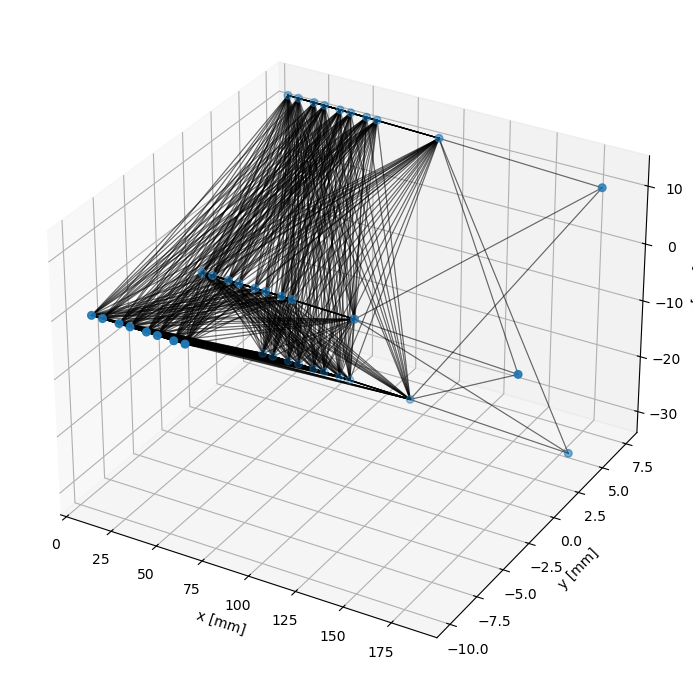

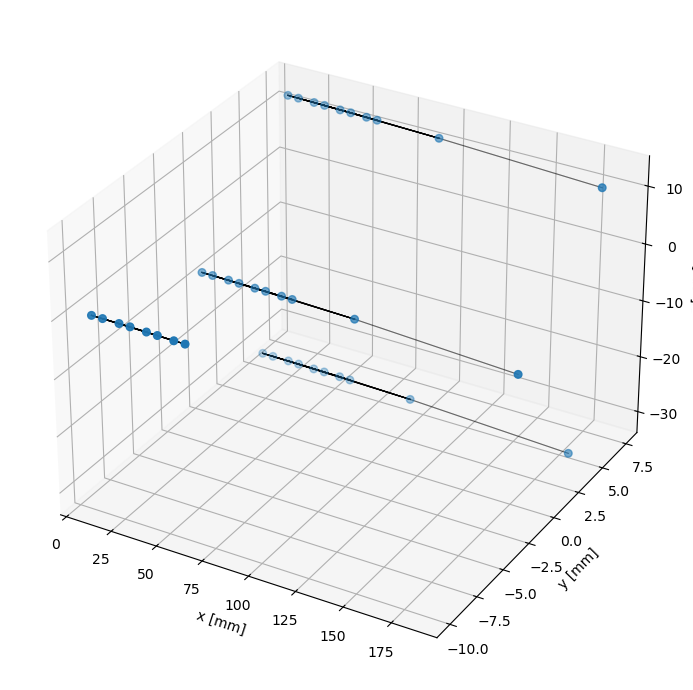

In [13]:
# Make GNN dataset
dataset = GTT.MyInMemoryDataset(df_graph, mode = "EC")

# Plot example graph
data = dataset[2]
GTT.plot_pyg_graph_3d(data, plot_truth=True)

In [14]:
# Split into training, validation, and test sets
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(42))

# Make DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_44325/2749194043.py:6: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_44325/2749194043.py:7: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_44325/2749194043.py:8: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Initialize Model and Optimizer

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [16]:
# Initialize model
hidden_size = 40

if use_Edep:
    model = models.MyIN_Edep(hidden_size).to(device)
else:
    model = models.MyIN(hidden_size).to(device)

total_trainable_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_trainable_params}")

# Load state dictionary and evaluate on test set
if use_Edep:
    model.load_state_dict(torch.load('/Users/mghrear/data/LDMX_GNN/models/IN_Edep_'+tracker_name+'_signal_state_dict.pt'))
else:
    model.load_state_dict(torch.load('/Users/mghrear/data/LDMX_GNN/models/IN_'+tracker_name+'_signal_state_dict.pt'))

Total trainable parameters: 18407


# Test the final model

In [17]:
test_loss, test_acc, test_TPR, test_TNR, labels, preds = GTT.test(model, device, test_loader)

print("test loss = ", test_loss)
print("test acc = ", test_acc)
print("test TPR = ", test_TPR)
print("test TNR = ", test_TNR)


test loss =  1.9403696312031276
test acc =  0.8223573468887305
test TPR =  0.033851304178193355
test TNR =  0.9998520499491635


Test AUROC: 0.87251348


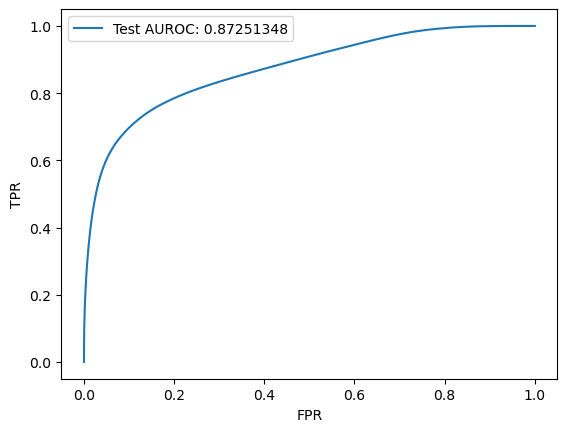

In [18]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, preds, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.8f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.8f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [41]:
for i in range(100):
    graph = test_dataset[i]
    # Analyze graph with model
    model.eval()
    data = graph.to(device)
    output = model(data.x, data.edge_index, data.edge_attr).squeeze(1).detach().cpu()
    graph.pred = output>0.5
    if True in data.pred:
        print(i)

6
7
9
13
16
19
20
21
29
30
34
35
43
51
56
57
66
68
76
80
85
86
87
89
91
92
96
97


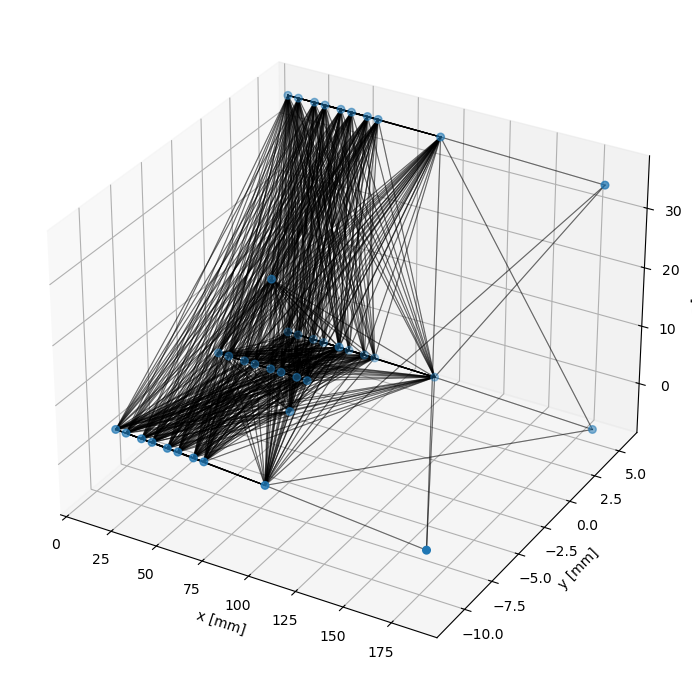

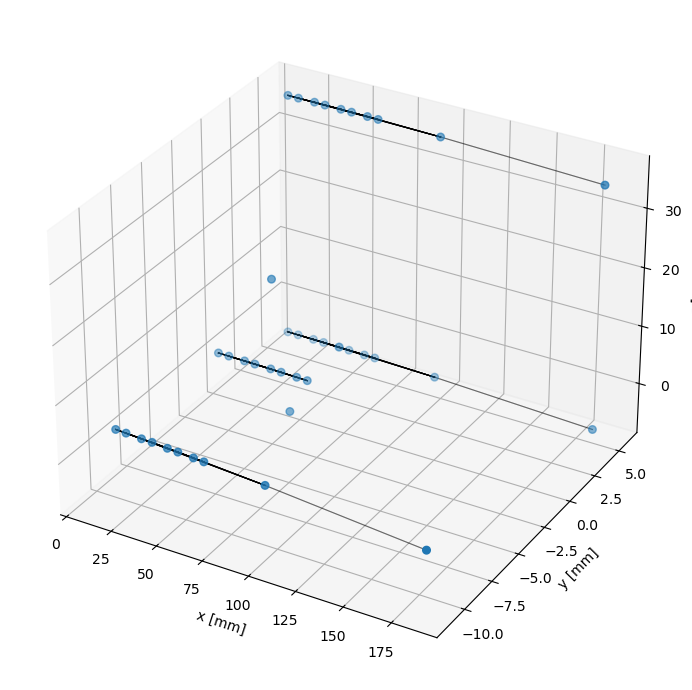

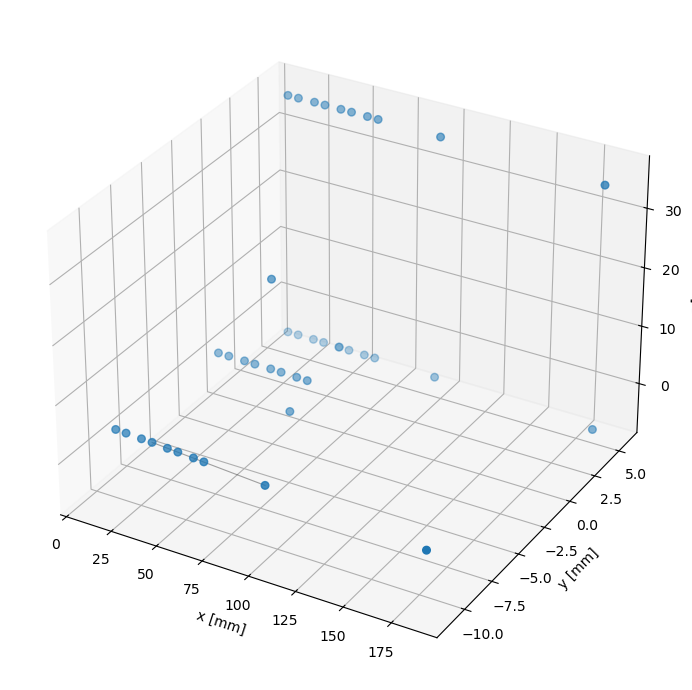

In [42]:
graph = test_dataset[6]

# Analyze graph with model
model.eval()
data = graph.to(device)

if use_Edep:
    output = model(data.x, data.Edep, data.edge_index, data.edge_attr).squeeze(1).detach().cpu()
else:
    output = model(data.x, data.edge_index, data.edge_attr).squeeze(1).detach().cpu()

graph.pred = output>0.5
GTT.plot_pyg_graph_3d(data, plot_truth=True, plot_pred=True)

In [43]:
# Minimum hits to construct a track, this should match whats used in TruthSeedProcessor (7 for Recoil tracker, 11 for Tagger tracker) 
min_nodes = 7
# Threshold used for absolute edge labeling
thres = 0.5
# Fraction of hits in a GNN track belonging to a single truth track needed to match the,
match_frac = 0.75

unmatched_GNNTracks = []

GNN_tracks = 0
Truth_tracks = 0
GNN_track_hits = []
Truth_track_hits = []

# Collect matched track info
matched_tracks = 0
matched_TruthTrack_index = []
matched_TruthTrack_TrackID = []
matched_TruthTrack_TruthP = []
matched_Fraction_Matched= []


# Check how many parameters the model's forward method takes
# If it's 4, the model take Edep as input feature
Nparams = len(inspect.signature(model.forward).parameters)

model.eval()
with torch.no_grad():
    for batch_idx, data in enumerate(test_loader):

        # Move datat to device 
        data = data.to(device)

        # GNN inference - depends on whether Edep is used
        if Nparams == 4:
            output = model(data.x, data.Edep, data.edge_index, data.edge_attr)
        else:
            output = model(data.x, data.edge_index, data.edge_attr)

        # Use GNN prediction to create track candidates via connected_components
        y_pred = output.squeeze()>thres
        data.edge_index = data.edge_index[:,y_pred]
        tracks = data.connected_components()

        # Keep only tracks passing min_nodes requirement
        rm_idx = []
        for index, track in enumerate(tracks):
            if track.x.shape[0] <  min_nodes:
                rm_idx += [index]
        for i in sorted(rm_idx, reverse=True):
            del tracks[i]

        # Get truth tracks
        truth_tracks = []
        # The corresponding index in the test dataset for each Truth Track
        Truth_Track_Indices = []
        # The Correspoonding Track ID for each Truth Track
        Truth_Track_IDs = []
        # The Truth Momentum for each Truth Track
        Truth_tracks_TruthPs = []
        for batch_ID in torch.unique(data.batch):
            for track_ID in np.arange(n_primaries)+1:
                # Create a filter for each batch ID and primary track ID, isolating truth tracks
                # Since track_ID only loops over the IDs of the primary tracks, it omits secondary tracks
                track_filter = (data.batch==batch_ID)*(data.truthID==track_ID)
                n_hits = data.x[track_filter].shape[0]

                if n_hits >= min_nodes:
                    truth_tracks += [data.x[track_filter]]
                    Truth_Track_Indices += [batch_idx*batch_size+batch_ID.item()]
                    Truth_Track_IDs += [track_ID]
                    Truth_tracks_TruthPs += [torch.mean(data.truthP[track_filter]).item()] # All entries should be the same after the filter is applied

        # Increment GNN track counter
        GNN_tracks += len(tracks)
        # Increment Truth track counter
        Truth_tracks += len(truth_tracks)
        # Keep track of the number of hits in GNN tracks
        GNN_track_hits += [track.x.shape[0] for track in tracks]
        # Keep track of the number of hits in Truth tracks
        Truth_track_hits += [track.shape[0] for track in truth_tracks]

        # Nested loop used to match Truth and GNN Tracks 
        for truth_track, truth_track_index, truth_track_ID, truth_track_truthP in zip(truth_tracks,Truth_Track_Indices,Truth_Track_IDs,Truth_tracks_TruthPs):

            for index, track in enumerate(tracks):

                # Find fraction of the GNN track that is contained in the truth track
                matches = (track.x[:, None, :] == truth_track[None, :, :]).all(dim=2).any(dim=1)
                count = matches.sum().item()

                # Tracks are matched based on the fraction of shared hits
                # This could be calculated as [matched hits] / [hits in GNN track] or [matched hits] / [hits in truth track]
                # By taking the minimum, I use whichever requirement is more strict 
                frac_contained1 = count/truth_track.shape[0]
                frac_contained2 = count/track.x.shape[0]
                frac_contained = np.minimum(frac_contained1,frac_contained2)


                # If we find a matching GNN track, record relevant data, remove GNN track from list, and break
                # A track is matched if over 75% of the GNN track as contained in the truth track
                if frac_contained >= match_frac:
                    # Find fraction of hits not present in truth track
                    matched_tracks += 1
                    matched_TruthTrack_index += [truth_track_index]
                    matched_TruthTrack_TrackID += [truth_track_ID]
                    matched_TruthTrack_TruthP += [truth_track_truthP]
                    matched_Fraction_Matched += [frac_contained]

                    # collect truth P
                    del tracks[index]
                    break

        unmatched_GNNTracks += tracks
                


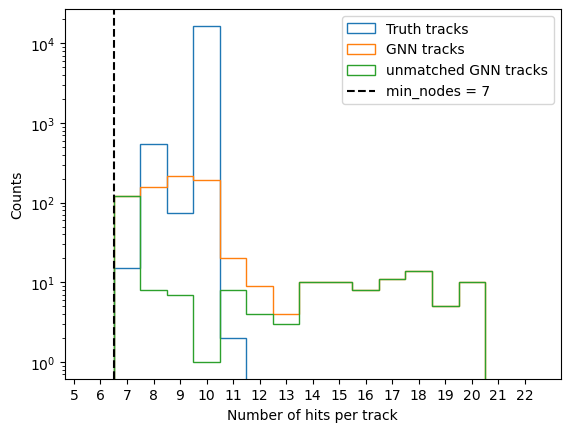

In [44]:
unmatched_nhits = []

for track in unmatched_GNNTracks:
    unmatched_nhits += [track.x.shape[0]]
    

plt.hist(Truth_track_hits, bins=np.arange(5, 22+0.5,1)+0.5, histtype= 'step' , label='Truth tracks')
plt.hist(GNN_track_hits, bins=np.arange(5, 22+0.5,1)+0.5, histtype= 'step' , label='GNN tracks')
plt.hist(unmatched_nhits, bins=np.arange(5, 22+0.5,1)+0.5, histtype= 'step' , label='unmatched GNN tracks')
plt.axvline(x=min_nodes-0.5, linestyle='--', color='k', label='min_nodes = '+str(min_nodes))
plt.xlabel('Number of hits per track')
plt.ylabel('Counts')
plt.yscale('log')
plt.xticks(range(5,23))
plt.legend()

In [45]:
# Track efficiency 
print( "Raw Track Eff.: ", matched_tracks/Truth_tracks)
# Truth efficinecy if we require more than min_nodes hits
print( "Truth Eff. (min_nodes = ", min_nodes, "): ", (Truth_tracks-np.sum(np.array(Truth_track_hits) < min_nodes))/Truth_tracks)
# Track efficiency if we only consider truth tracks with 4 or more hits (since we require min_nodes = 4 to reconstruct a track)
print( "Track Eff. (min_nodes = ", min_nodes, "): ", matched_tracks/(Truth_tracks-np.sum(np.array(Truth_track_hits) < min_nodes)))
# Fake rate
print( "Fake Rate: ", (GNN_tracks-matched_tracks)/Truth_tracks)

Raw Track Eff.:  0.033418426549083315
Truth Eff. (min_nodes =  7 ):  1.0
Track Eff. (min_nodes =  7 ):  0.033418426549083315
Fake Rate:  0.012705964260849386


Text(0, 0.5, 'No. tracks')

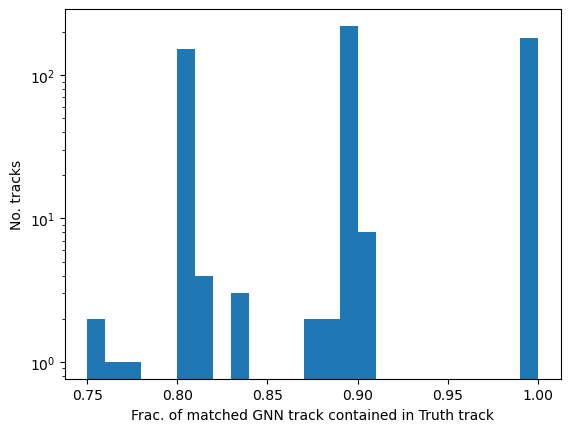

In [46]:
plt.hist(matched_Fraction_Matched,bins=np.arange(0.75,1.002,0.01))
plt.yscale('log')
plt.xlabel("Frac. of matched GNN track contained in Truth track")
plt.ylabel("No. tracks")